# AlphaGenome pretraining SSU — K562 tracks

Loads K562 SSU values directly from the AlphaGenome pretraining TFRecords to check for data mismatch with our computed SSUs.

**Data location:** `gs://alphagenome-datasets/v1/train/` (public GCS bucket, no auth required)  
**Bundle:** `SPLICE_SITE_USAGE` — 250 shards of `data_chrAll_NNN-250.gz.tfrecord`  
**Tensor shape per interval:** `(~1 052 672, 734)` in `float16` (1 bp resolution, 734 SSU tracks)  
**Track order:** matches `track_metadata.parquet` filtered to `output_type == 'splice_sites_usage'`

**Required env:** `alphagenome` (has `alphagenome_research` + TensorFlow).  
**SSL fix:** on this cluster `CURL_CA_BUNDLE` must be set to certifi's bundle *before* TF is imported.

In [1]:
# SSL fix — must happen before tensorflow is imported
import os
import certifi
os.environ["CURL_CA_BUNDLE"] = certifi.where()
os.environ["SSL_CERT_FILE"]  = certifi.where()

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.stats import pearsonr
from alphagenome_research.io import bundles as bundles_lib
from alphagenome_research.io import dataset as dataset_lib
from alphagenome.models import dna_model
from alphagenome.data import fold_intervals

ROOT                 = ".."
GCS_TRAIN_PATH       = "gs://alphagenome-datasets/v1/train/"
TRACK_METADATA_PATH  = os.path.join(ROOT, "data/raw/articles/Avsec2026/alphagenome_pytorch/track_metadata.parquet")
SF3B1_SSU_DIR        = os.path.join(ROOT, "data/raw/ENA/sf3b1mut/STAR")

OUTPUT_DIR = os.path.join("pdfs", "pretrain_ssu")
os.makedirs(OUTPUT_DIR, exist_ok=True)

I0000 00:00:1781603351.910756  911449 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781603351.982770  911449 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 AMX_FP16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1781603357.558492  911449 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


/users/diasfrazer/manglada/miniforge3/envs/alphagenome/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## K562 track indices

In [2]:
track_meta = pd.read_parquet(TRACK_METADATA_PATH)
ssu_tracks = (
    track_meta
    .query("output_type == 'splice_sites_usage'")
    .reset_index(drop=True)  # row index = column in the TFRecord tensor
)

# K562: EFO:0002067, polyA plus RNA-seq
k562_tracks = ssu_tracks[
    ssu_tracks["track_name"].str.contains("EFO:0002067") &
    ssu_tracks["track_name"].str.contains("polyA plus")
]
print(k562_tracks[["track_name", "track_strand"]].assign(tensor_col=k562_tracks.index).to_string())

K562_IDX_POS = k562_tracks[k562_tracks["track_strand"] == "+"].index[0]
K562_IDX_NEG = k562_tracks[k562_tracks["track_strand"] == "-"].index[0]
print("\nK562 + strand column:", K562_IDX_POS)
print("K562 - strand column:", K562_IDX_NEG)

                               track_name track_strand  tensor_col
139  usage_EFO:0002067 polyA plus RNA-seq            +         139
506  usage_EFO:0002067 polyA plus RNA-seq            -         506

K562 + strand column: 139
K562 - strand column: 506


In [3]:
k562_tracks

,track_name,track_strand,ontology_curie,assay_title,biosample_name,biosample_type,organism,output_type,gtex_tissue,transcription_factor,histone_mark
139,usage_EFO:0002067 polyA plus RNA-seq,+,EFO:0002067,polyA plus RNA-seq,K562,cell_line,human,splice_sites_usage,,None,None
506,usage_EFO:0002067 polyA plus RNA-seq,-,EFO:0002067,polyA plus RNA-seq,K562,cell_line,human,splice_sites_usage,,None,None


## Load K562 SSU from a few TFRecord shards

In [4]:
ssu_tfdf = dataset_lib.get_tfrecords_df(
    organism=dna_model.Organism.HOMO_SAPIENS,
    bundle=bundles_lib.BundleName.SPLICE_SITES_USAGE,
    fold_split=dna_model.ModelVersion.ALL_FOLDS,
    subset=fold_intervals.Subset.TRAIN,
    path=GCS_TRAIN_PATH,
)
print("SSU shards available:", len(ssu_tfdf))

N_SHARDS   = 5   # shards to read (each has ~1 interval per shard file)
N_INTERVALS = 1  # intervals to take per shard

parser = dataset_lib._get_parse_function(bundles_lib.BundleName.SPLICE_SITES_USAGE)

records = []
for shard_idx in range(N_SHARDS):
    path = ssu_tfdf.iloc[shard_idx]["path"]
    ds = tf.data.TFRecordDataset(path, compression_type="GZIP").map(parser)
    for element in ds.take(N_INTERVALS):
        chrom = element["interval/chromosome"].numpy().decode()
        start = int(element["interval/start"].numpy())
        ssu   = element["splice_site_usage"].numpy()  # (seq_len, 734) float16

        k562_pos = ssu[:, K562_IDX_POS].astype(float)
        k562_neg = ssu[:, K562_IDX_NEG].astype(float)
        nonzero  = (k562_pos > 0) | (k562_neg > 0)

        for bp in np.where(nonzero)[0]:
            records.append({
                "chrom":          chrom,
                "pos":            start + int(bp),
                "ssu_pos_strand": float(k562_pos[bp]),
                "ssu_neg_strand": float(k562_neg[bp]),
            })

df_k562 = pd.DataFrame(records)
print("Non-zero K562 SSU sites:", len(df_k562))
df_k562.head()

W0000 00:00:1781603361.678393  911449 google_auth_provider.cc:196] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Could not resolve hostname', error details: Could not resolve host: metadata.google.internal".


SSU shards available: 250


W0000 00:00:1781603362.488223  911449 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
I0000 00:00:1781603362.618145  911512 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


Non-zero K562 SSU sites: 949


,chrom,pos,ssu_pos_strand,ssu_neg_strand
0,chr7,30128878,0.379395,0.0
1,chr7,30129265,0.909180,0.0
2,chr7,30135297,0.981445,0.0
3,chr7,30146176,0.688965,0.0
4,chr7,30146298,0.754883,0.0


## Forward pass: verify TFRecord SSU interpretation

Run the pretrained AlphaGenome JAX model on the same interval loaded from the TFRecord above and compare predicted SSU with TFRecord SSU.

**Requires:** a GPU (or explicitly pass a CPU device — much slower). Model is downloaded from HuggingFace on first run (~several GB).

In [5]:
import jax
from alphagenome.data import genome
from alphagenome.models import dna_output
from alphagenome_research.model import dna_model as ag_model

# orbax requires absolute paths
ROOT_ABS        = os.path.abspath(ROOT)
FASTA_PATH      = os.path.join(ROOT_ABS, "data/raw/GENCODE/release_46/GRCh38.primary_assembly.genome.fa.gz")
CHECKPOINT_PATH = os.path.join(ROOT_ABS, "data/raw/articles/Avsec2026/alphagenome_jax/fold-1")

print("Checkpoint:", CHECKPOINT_PATH)
print("FASTA:     ", FASTA_PATH)

organism_settings = {
    ag_model.Organism.HOMO_SAPIENS: ag_model.OrganismSettings(
        fasta_path=FASTA_PATH,
    )
}

# pass device explicitly to bypass the GPU-only guard
device = jax.local_devices()[0]
print("Using device:", device)

model = ag_model.create(
    CHECKPOINT_PATH,
    organism_settings=organism_settings,
    device=device,
)
print("Model loaded.")

Checkpoint: /users/diasfrazer/manglada/projects/alphagenome_finetuning_rna/data/raw/articles/Avsec2026/alphagenome_jax/fold-1
FASTA:      /users/diasfrazer/manglada/projects/alphagenome_finetuning_rna/data/raw/GENCODE/release_46/GRCh38.primary_assembly.genome.fa.gz


Using device: cuda:0


Model loaded.


In [6]:
# re-read the first shard to get exact interval coordinates
_shard_path = ssu_tfdf.iloc[0]["path"]
_ds = tf.data.TFRecordDataset(_shard_path, compression_type="GZIP").map(parser)
_elem = next(iter(_ds))

IV_CHROM = _elem["interval/chromosome"].numpy().decode()
IV_START = int(_elem["interval/start"].numpy())
IV_WIDTH = int(_elem["splice_site_usage"].numpy().shape[0])
IV_END   = IV_START + IV_WIDTH

print("Interval: {}:{}-{}  ({} bp)".format(IV_CHROM, IV_START, IV_END, IV_WIDTH))

Interval: chr7:30126437-31179109  (1052672 bp)


In [7]:
interval = genome.Interval(chromosome=IV_CHROM, start=IV_START, end=IV_END)

output = model.predict_interval(
    interval,
    requested_outputs=[dna_output.OutputType.SPLICE_SITE_USAGE],
    ontology_terms=["EFO:0002067"],
)

ssu_pred   = output.splice_site_usage.values   # (seq_len, n_k562_tracks)
ssu_meta   = output.splice_site_usage.metadata # DataFrame: name, strand, ...

print("Predicted SSU shape:", ssu_pred.shape)
print(ssu_meta[["name", "strand"]])

Predicted SSU shape: (1052672, 4)
                                     name strand
139  usage_EFO:0002067 polyA plus RNA-seq      +
140       usage_EFO:0002067 total RNA-seq      +
506  usage_EFO:0002067 polyA plus RNA-seq      -
507       usage_EFO:0002067 total RNA-seq      -


Pearson r = 0.8516  (n = 266)


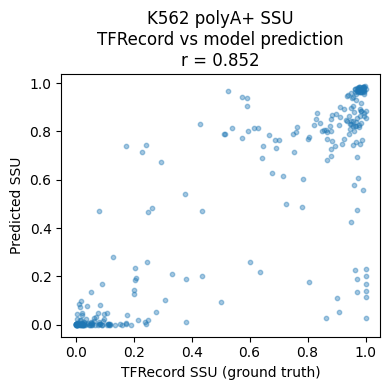

In [8]:
# map predicted columns to strands using metadata
pos_col = int(np.where(ssu_meta["strand"].values == "+")[0][0])
neg_col = int(np.where(ssu_meta["strand"].values == "-")[0][0])

# restrict df_k562 to this interval
df_iv = df_k562[
    (df_k562["chrom"] == IV_CHROM) &
    (df_k562["pos"] >= IV_START) &
    (df_k562["pos"] < IV_END)
].copy()
df_iv["bp"] = df_iv["pos"] - IV_START

df_iv["pred_pos"] = ssu_pred[df_iv["bp"].values, pos_col]
df_iv["pred_neg"] = ssu_pred[df_iv["bp"].values, neg_col]

# stack + and - strand into one table for a single scatter
df_pos = df_iv[["ssu_pos_strand", "pred_pos"]].rename(
    columns={"ssu_pos_strand": "tfrecord_ssu", "pred_pos": "predicted_ssu"})
df_neg = df_iv[["ssu_neg_strand", "pred_neg"]].rename(
    columns={"ssu_neg_strand": "tfrecord_ssu", "pred_neg": "predicted_ssu"})
df_cmp = pd.concat([df_pos, df_neg], ignore_index=True)
df_cmp = df_cmp[df_cmp["tfrecord_ssu"] > 0]

r, p = pearsonr(df_cmp["tfrecord_ssu"], df_cmp["predicted_ssu"])
print("Pearson r = {:.4f}  (n = {})".format(r, len(df_cmp)))

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(df_cmp["tfrecord_ssu"], df_cmp["predicted_ssu"], alpha=0.4, s=10, rasterized=True)
ax.set_xlabel("TFRecord SSU (ground truth)")
ax.set_ylabel("Predicted SSU")
ax.set_title("K562 polyA+ SSU\nTFRecord vs model prediction\nr = {:.3f}".format(r))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "tfrecord_vs_predicted_ssu.pdf"), dpi=150)
plt.show()

## Conclusions

**TFRecord interpretation is correct.**  
Pearson r ≈ 0.85 between AlphaGenome's sequence-based SSU predictions and the TFRecord ground-truth values (n = 266 non-zero sites from 5 TRAIN shards, chr7) confirms that:

- Track indices **139 (+) and 506 (-)** in the SPLICE_SITE_USAGE tensor correspond to K562 polyA+ RNA-seq (EFO:0002067), as listed in `track_metadata.parquet`.
- TFRecord positions are **0-based**; adding +1 converts to the 1-based `exon_pos` used by `compute_ssu.py`.
- The orbax checkpoint at `data/raw/articles/Avsec2026/alphagenome_jax/fold-1` loads correctly with `ag_model.create()` given an **absolute** path.